In [3]:
import pandas as pd 

In [72]:
miami_fl = pd.read_csv('../scripts/climate_causal_model/zcta_results_New York, NY.csv')

#look at pre-covid 2015-2019
miami_fl['c'] = miami_fl.groupby('zip').transform('count')['PER CAPITA INCOME']
miami_fl['r'] = miami_fl.groupby('zip').cumcount()
miami_fl = miami_fl.loc[(miami_fl['c']==8)&(miami_fl['r']<=4)]

miami_fl_agg = miami_fl.groupby(['zip']).mean().reset_index()

miami_fl_agg

,zip,Unnamed: 0,PER CAPITA INCOME,TOTAL POPULATION ESTIMATE,homes_sold,treatment_effect,treatment_effect_no_corr,home_price,risk_regime,income_decay,population_decay,marketdemand_decay,marginalized,c,r
0,10001,3.0,0.025067,0.012932,0.299801,-0.121016,-0.026020,0.123812,0.0,0.4,0.4,0.4,0.4,8.0,2.0
1,10002,12.0,0.041257,-0.016185,0.229859,-0.694419,-0.027297,0.440819,0.0,0.0,1.0,0.6,0.6,8.0,2.0
2,10003,21.0,0.044896,-0.008600,-0.063648,-0.107716,-0.009008,0.118981,0.2,0.0,0.8,0.4,0.2,8.0,2.0
3,10004,30.0,0.155074,0.006782,-0.161345,0.053317,0.052078,0.092746,0.0,0.0,0.6,0.6,0.4,8.0,2.0
4,10006,39.0,0.060643,0.012091,0.065886,-0.855475,-0.010830,0.542104,0.0,0.0,0.4,0.4,0.2,8.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,11691,2260.0,0.069539,0.013632,-0.106396,-0.130129,-0.023540,0.138056,0.4,0.0,0.2,0.4,0.2,8.0,2.0
239,11692,2269.0,0.046226,0.033994,0.011288,-0.092253,-0.024328,0.136723,0.6,0.0,0.0,0.6,0.0,8.0,2.0
240,11693,2278.0,0.030228,0.031228,-0.022001,-0.126047,-0.051600,0.061012,0.8,0.2,0.0,0.6,0.2,8.0,2.0
241,11694,2287.0,0.024648,0.004705,-0.029453,0.079182,-0.020596,0.019005,0.0,0.2,0.4,0.6,0.4,8.0,2.0


In [73]:
import duckdb 
con = duckdb.connect('../datasets/combined_data2.db')
miami_fl_raw_agg = con.query('''
        select zip,sum(claimCounts) as claims,sum(numEvents) as events,sum(totalClaimZip) as claim_amt,sum(totalLossesZip) as loss_amt
        from Newyorkcensus_claims 
        where year < 2020
        group by 1;
''').df()
miami_fl_raw_agg = miami_fl_raw_agg.fillna(0)
miami_fl_combined_agg = miami_fl_agg.merge(miami_fl_raw_agg, how='inner', on='zip')
miami_fl_combined_agg

,zip,Unnamed: 0,PER CAPITA INCOME,TOTAL POPULATION ESTIMATE,homes_sold,treatment_effect,treatment_effect_no_corr,home_price,risk_regime,income_decay,population_decay,marketdemand_decay,marginalized,c,r,claims,events,claim_amt,loss_amt
0,10001,3.0,0.025067,0.012932,0.299801,-0.121016,-0.026020,0.123812,0.0,0.4,0.4,0.4,0.4,8.0,2.0,0.0,0.0,0.00,0.0
1,10002,12.0,0.041257,-0.016185,0.229859,-0.694419,-0.027297,0.440819,0.0,0.0,1.0,0.6,0.6,8.0,2.0,0.0,0.0,0.00,0.0
2,10003,21.0,0.044896,-0.008600,-0.063648,-0.107716,-0.009008,0.118981,0.2,0.0,0.8,0.4,0.2,8.0,2.0,1.0,0.0,10515.76,11431.0
3,10004,30.0,0.155074,0.006782,-0.161345,0.053317,0.052078,0.092746,0.0,0.0,0.6,0.6,0.4,8.0,2.0,0.0,0.0,0.00,0.0
4,10006,39.0,0.060643,0.012091,0.065886,-0.855475,-0.010830,0.542104,0.0,0.0,0.4,0.4,0.2,8.0,2.0,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,11691,2260.0,0.069539,0.013632,-0.106396,-0.130129,-0.023540,0.138056,0.4,0.0,0.2,0.4,0.2,8.0,2.0,20.0,0.0,15207.98,22692.0
239,11692,2269.0,0.046226,0.033994,0.011288,-0.092253,-0.024328,0.136723,0.6,0.0,0.0,0.6,0.0,8.0,2.0,31.0,0.0,147458.67,188790.0
240,11693,2278.0,0.030228,0.031228,-0.022001,-0.126047,-0.051600,0.061012,0.8,0.2,0.0,0.6,0.2,8.0,2.0,9.0,0.0,82657.76,119550.0
241,11694,2287.0,0.024648,0.004705,-0.029453,0.079182,-0.020596,0.019005,0.0,0.2,0.4,0.6,0.4,8.0,2.0,3.0,0.0,487.32,1721.0



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


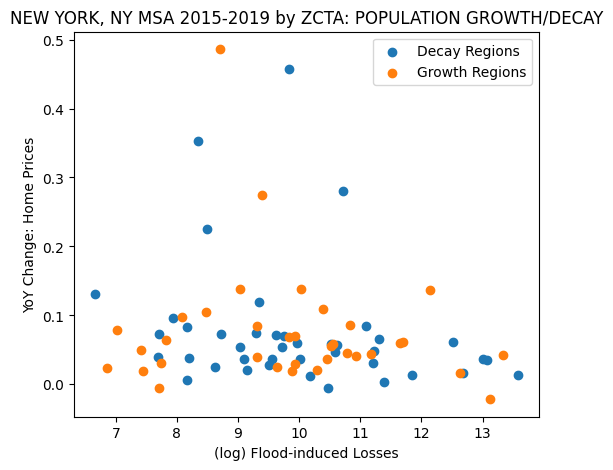

In [75]:
!pip install matplotlib
!pip install numpy 
import numpy as np
import matplotlib.pyplot as plt 

plt.rcParams['figure.figsize']=(6,5)

plt.scatter(
    np.log(miami_fl_combined_agg.loc[miami_fl_combined_agg['TOTAL POPULATION ESTIMATE'] <= 0]['loss_amt']), 
    miami_fl_combined_agg.loc[miami_fl_combined_agg['TOTAL POPULATION ESTIMATE'] <= 0]['home_price'], 
    label='Decay Regions'
)

plt.scatter(
    np.log(miami_fl_combined_agg.loc[miami_fl_combined_agg['TOTAL POPULATION ESTIMATE'] > 0]['loss_amt']), 
    miami_fl_combined_agg.loc[miami_fl_combined_agg['TOTAL POPULATION ESTIMATE'] > 0]['home_price'], 
    label='Growth Regions'
)
plt.title('NEW YORK, NY MSA 2015-2019 by ZCTA: POPULATION GROWTH/DECAY')
plt.xlabel('(log) Flood-induced Losses')
plt.ylabel('YoY Change: Home Prices')
plt.legend() 
plt.show()

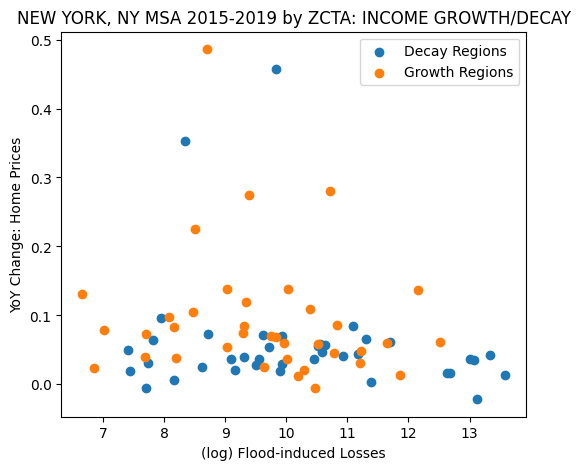

In [81]:
plt.scatter(
    np.log(miami_fl_combined_agg.loc[miami_fl_combined_agg['PER CAPITA INCOME'] <= 0.04]['loss_amt']), 
    miami_fl_combined_agg.loc[miami_fl_combined_agg['PER CAPITA INCOME'] <= 0.04]['home_price'], 
    label='Decay Regions'
)

plt.scatter(
    np.log(miami_fl_combined_agg.loc[miami_fl_combined_agg['PER CAPITA INCOME'] > 0.04]['loss_amt']), 
    miami_fl_combined_agg.loc[miami_fl_combined_agg['PER CAPITA INCOME'] > 0.04]['home_price'], 
    label='Growth Regions'
)

plt.title('NEW YORK, NY MSA 2015-2019 by ZCTA: INCOME GROWTH/DECAY')
plt.xlabel('(log) Flood-induced Losses')
plt.ylabel('YoY Change: Home Prices')
plt.legend() 
plt.show()

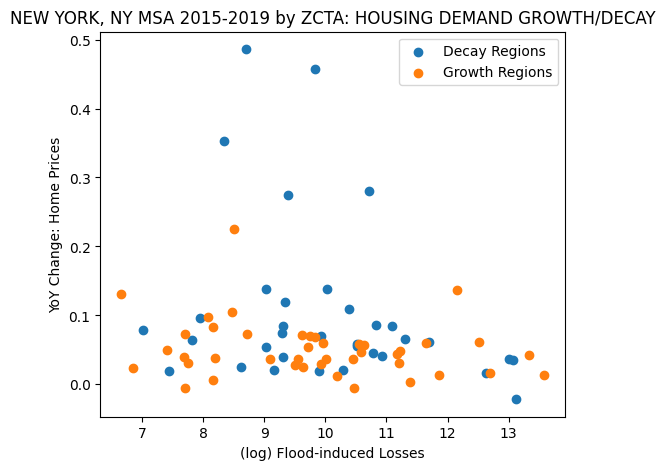

In [77]:
plt.scatter(
    np.log(miami_fl_combined_agg.loc[miami_fl_combined_agg['homes_sold'] <= 0.0]['loss_amt']), 
    miami_fl_combined_agg.loc[miami_fl_combined_agg['homes_sold'] <= 0.0]['home_price'], 
    label='Decay Regions'
)

plt.scatter(
    np.log(miami_fl_combined_agg.loc[miami_fl_combined_agg['homes_sold'] > 0.0]['loss_amt']), 
    miami_fl_combined_agg.loc[miami_fl_combined_agg['homes_sold'] > 0.0]['home_price'], 
    label='Growth Regions'
)

plt.title('NEW YORK, NY MSA 2015-2019 by ZCTA: HOUSING DEMAND GROWTH/DECAY')
plt.xlabel('(log) Flood-induced Losses')
plt.ylabel('YoY Change: Home Prices')
plt.legend() 
plt.show()